# Analyzing Label Noise and Annotator Reliability in the SNLI Dataset

## Introduction

Large language models rely heavily on high-quality labeled datasets. However, human annotations often contain disagreement and inconsistencies that introduce **label noise**.

This notebook analyzes the Stanford Natural Language Inference (SNLI) dataset to investigate:

• Annotator agreement and reliability  
• Potential label noise in the dataset  
• The impact of annotator quality on model training

Understanding these factors can help improve dataset quality and model performance.

## Objective

In this notebook, I explore several key questions:

1. What is the structure of the preference dataset?
2. How consistent are human annotators?
3. Where might label noise occur?
4. How can we improve training data quality?

## Skills Demonstrated
- Python data analysis
- Exploratory Data Analysis (EDA)
- Human feedback dataset analysis
- AI evaluation reasoning
- Annotator reliability analysis

## Tools Used
- Python
- Pandas
- NumPy
- Jupyter / Google Colab

## Why this matters
As AI systems increasingly rely on human feedback for training, **data quality and annotator reliability become critical factors in building safe and effective models.**

## Problem Framing

Large language models rely heavily on high-quality labeled datasets. However, human annotations can be inconsistent, introducing **label noise** that may negatively affect model performance.

The Stanford Natural Language Inference (SNLI) dataset is commonly used to train models that determine the relationship between two sentences:

- Entailment
- Neutral
- Contradiction

Each example in SNLI is labeled by multiple annotators. Disagreements between annotators may indicate ambiguity or labeling errors.

This analysis focuses on understanding:

• how reliable human annotations are  
• where label noise may occur  
• how annotation quality might affect model training

## Goal of the Model

The goal of the model trained on the SNLI dataset is to perform **Natural Language Inference (NLI)**.

Given two sentences:

- a **premise**
- a **hypothesis**

The model predicts the relationship between them:

1. Entailment – the hypothesis logically follows from the premise  
2. Neutral – the relationship is uncertain  
3. Contradiction – the hypothesis conflicts with the premise

High-quality annotations are critical because noisy labels can cause the model to learn incorrect patterns.

## Model Evaluation Metrics

Models trained on SNLI are typically evaluated using **classification metrics**.

Common evaluation metrics include:

• **Accuracy** – percentage of correct predictions  
• **Precision** – how often predicted labels are correct  
• **Recall** – how many true labels are successfully identified  
• **F1 Score** – balance between precision and recall

Because the task involves three classes (entailment, neutral, contradiction), these metrics are usually calculated for each class and averaged.

In addition to model performance metrics, this analysis also evaluates **annotation quality**, including:

• annotator agreement with gold labels  
• disagreement between annotators  
• potential label noise

## Dataset Description

We use the SNLI dataset, which contains sentence pairs labeled with one of three relationships:

- Entailment
- Neutral
- Contradiction

Each example is annotated by multiple human labelers, and the final **gold label** represents the consensus annotation.

Because multiple annotators contribute labels, we can analyze agreement patterns to evaluate dataset quality.

## Dataset Exploration

We first inspect the dataset structure and key columns.  
This helps us understand how annotator labels are recorded and how the final gold label is determined.

In [53]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stanfordu/stanford-natural-language-inference-corpus")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stanford-natural-language-inference-corpus' dataset.
Path to dataset files: /kaggle/input/stanford-natural-language-inference-corpus


In [54]:
import pandas as pd


train_path = f"{path}/snli_1.0_train.csv"
df_train = pd.read_csv(train_path)

In [55]:
df_train.head()

,gold_label,sentence1_binary_parse,sentence2_binary_parse,sentence1_parse,sentence2_parse,sentence1,sentence2,captionID,pairID,label1,label2,label3,label4,label5
0,neutral,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,( ( A person ) ( ( is ( ( training ( his horse...,(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,A person is training his horse for a competition.,3416050480.jpg#4,3416050480.jpg#4r1n,neutral,NaN,NaN,NaN,NaN
1,contradiction,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,( ( A person ) ( ( ( ( is ( at ( a diner ) ) )...,(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",3416050480.jpg#4,3416050480.jpg#4r1c,contradiction,NaN,NaN,NaN,NaN
2,entailment,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,"( ( A person ) ( ( ( ( is outdoors ) , ) ( on ...",(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",3416050480.jpg#4,3416050480.jpg#4r1e,entailment,NaN,NaN,NaN,NaN
3,neutral,( Children ( ( ( smiling and ) waving ) ( at c...,( They ( are ( smiling ( at ( their parents ) ...,(ROOT (NP (S (NP (NNP Children)) (VP (VBG smil...,(ROOT (S (NP (PRP They)) (VP (VBP are) (VP (VB...,Children smiling and waving at camera,They are smiling at their parents,2267923837.jpg#2,2267923837.jpg#2r1n,neutral,NaN,NaN,NaN,NaN
4,entailment,( Children ( ( ( smiling and ) waving ) ( at c...,( There ( ( are children ) present ) ),(ROOT (NP (S (NP (NNP Children)) (VP (VBG smil...,(ROOT (S (NP (EX There)) (VP (VBP are) (NP (NN...,Children smiling and waving at camera,There are children present,2267923837.jpg#2,2267923837.jpg#2r1e,entailment,NaN,NaN,NaN,NaN


In [56]:
df_train.describe()

,gold_label,sentence1_binary_parse,sentence2_binary_parse,sentence1_parse,sentence2_parse,sentence1,sentence2,captionID,pairID,label1,label2,label3,label4,label5
count,550152,550152,550146,550152,550152,550152,550146,550152,550152,550152,39370,39395,39383,36914
unique,4,150736,479906,150736,479908,150736,480040,151196,550152,3,3,3,3,3
top,entailment,( ( ( A dog ) ( in ( a field ) ) ) . ),( ( A man ) ( ( is sleeping ) . ) ),(ROOT (NP (NP (DT A) (NN dog)) (PP (IN in) (NP...,(ROOT (S (NP (DT A) (NN man)) (VP (VBZ is) (VP...,A dog in a field.,A man is sleeping.,7261359916.jpg#2,7979219683.jpg#2r1e,neutral,contradiction,contradiction,contradiction,entailment
freq,183416,33,335,33,335,33,335,15,1,183384,13478,13728,13701,12768


In [57]:
df_train.columns.unique()

Index(['gold_label', 'sentence1_binary_parse', 'sentence2_binary_parse',
       'sentence1_parse', 'sentence2_parse', 'sentence1', 'sentence2',
       'captionID', 'pairID', 'label1', 'label2', 'label3', 'label4',
       'label5'],
      dtype='object')

In [58]:
df_train = df_train[df_train['gold_label'] != '-']

## Annotator Reliability

Since each example is labeled by multiple annotators, we measure:

• agreement rate  
• disagreement patterns  
• annotator accuracy relative to gold labels

In [59]:
# Filter out the NA in label 1.
df_train['label1'].isna().sum()


df_train_label1 = df_train.drop(columns=['label2', 'label3', 'label4','label5'])

df_train_label1.head()

,gold_label,sentence1_binary_parse,sentence2_binary_parse,sentence1_parse,sentence2_parse,sentence1,sentence2,captionID,pairID,label1
0,neutral,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,( ( A person ) ( ( is ( ( training ( his horse...,(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,A person is training his horse for a competition.,3416050480.jpg#4,3416050480.jpg#4r1n,neutral
1,contradiction,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,( ( A person ) ( ( ( ( is ( at ( a diner ) ) )...,(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",3416050480.jpg#4,3416050480.jpg#4r1c,contradiction
2,entailment,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,"( ( A person ) ( ( ( ( is outdoors ) , ) ( on ...",(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",3416050480.jpg#4,3416050480.jpg#4r1e,entailment
3,neutral,( Children ( ( ( smiling and ) waving ) ( at c...,( They ( are ( smiling ( at ( their parents ) ...,(ROOT (NP (S (NP (NNP Children)) (VP (VBG smil...,(ROOT (S (NP (PRP They)) (VP (VBP are) (VP (VB...,Children smiling and waving at camera,They are smiling at their parents,2267923837.jpg#2,2267923837.jpg#2r1n,neutral
4,entailment,( Children ( ( ( smiling and ) waving ) ( at c...,( There ( ( are children ) present ) ),(ROOT (NP (S (NP (NNP Children)) (VP (VBG smil...,(ROOT (S (NP (EX There)) (VP (VBP are) (NP (NN...,Children smiling and waving at camera,There are children present,2267923837.jpg#2,2267923837.jpg#2r1e,entailment


In [60]:
# I want to check how many rows are disagreed.

disagree = df_train_label1[df_train_label1['label1'] != df_train_label1['gold_label']]

disagree.head()

,gold_label,sentence1_binary_parse,sentence2_binary_parse,sentence1_parse,sentence2_parse,sentence1,sentence2,captionID,pairID,label1
11,neutral,( ( An ( older man ) ) ( ( ( sits ( with ( ( h...,( ( An ( elderly man ) ) ( ( sits ( in ( a ( s...,(ROOT (S (NP (DT An) (JJR older) (NN man)) (VP...,(ROOT (S (NP (DT An) (JJ elderly) (NN man)) (V...,An older man sits with his orange juice at a s...,An elderly man sits in a small shop.,4804607632.jpg#0,4804607632.jpg#0r1e,entailment
43,entailment,( ( People ( ( ( waiting ( to ( get ( on ( a t...,( There ( are ( people ( just ( getting ( on (...,(ROOT (NP (NP (NNS People)) (VP (VP (VBG waiti...,(ROOT (S (NP (EX There)) (VP (VBP are) (NP (NP...,People waiting to get on a train or just getti...,There are people just getting on a train,4934873039.jpg#2,4934873039.jpg#2r1c,contradiction
452,entailment,( ( A ( young woman ) ) ( ( tries ( to ( ( sti...,( ( The woman ) ( ( has ( ( one foot ) ( in ( ...,(ROOT (S (NP (DT A) (JJ young) (NN woman)) (VP...,(ROOT (S (NP (DT The) (NN woman)) (VP (VBZ has...,A young woman tries to stick her foot in a fou...,The woman has one foot in the air.,856985136.jpg#3,856985136.jpg#3r1n,neutral
472,neutral,( ( ( a man ) ( in red ) ) ( ( ( stands ( with...,( ( ( A man ) ( ( wearing ( ( red standing ) (...,(ROOT (S (NP (NP (DT a) (NN man)) (PP (IN in) ...,(ROOT (NP (NP (DT A) (NN man)) (VP (VBG wearin...,a man in red stands with his child at the beach.,A man wearing red standing with his child at a...,2946464027.jpg#2,2946464027.jpg#2r1e,entailment
534,contradiction,( ( ( Two ( elderly men ) ) ( having ( a conve...,( ( The men ) ( are ( ( ( drinking coffee ) an...,(ROOT (S (S (NP (CD Two) (JJ elderly) (NNS men...,(ROOT (S (NP (DT The) (NNS men)) (VP (VBP are)...,"Two elderly men having a conversation, snow co...",The men are drinking coffee and having some co...,3525332706.jpg#1,3525332706.jpg#1r1n,neutral


In [61]:
# Check how many are disgreed.

len(disagree)

2540

In [62]:
# Check what the percentage of disagree 0.6%

label1_disagree_percent = (len(disagree) / len(df_train_label1)) * 100
label1_disagree_percent

0.4623503049873764

In [63]:
agree = df_train_label1[df_train_label1['label1'] == df_train_label1['gold_label']]

agree.head()

,gold_label,sentence1_binary_parse,sentence2_binary_parse,sentence1_parse,sentence2_parse,sentence1,sentence2,captionID,pairID,label1
0,neutral,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,( ( A person ) ( ( is ( ( training ( his horse...,(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,A person is training his horse for a competition.,3416050480.jpg#4,3416050480.jpg#4r1n,neutral
1,contradiction,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,( ( A person ) ( ( ( ( is ( at ( a diner ) ) )...,(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",3416050480.jpg#4,3416050480.jpg#4r1c,contradiction
2,entailment,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,"( ( A person ) ( ( ( ( is outdoors ) , ) ( on ...",(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",3416050480.jpg#4,3416050480.jpg#4r1e,entailment
3,neutral,( Children ( ( ( smiling and ) waving ) ( at c...,( They ( are ( smiling ( at ( their parents ) ...,(ROOT (NP (S (NP (NNP Children)) (VP (VBG smil...,(ROOT (S (NP (PRP They)) (VP (VBP are) (VP (VB...,Children smiling and waving at camera,They are smiling at their parents,2267923837.jpg#2,2267923837.jpg#2r1n,neutral
4,entailment,( Children ( ( ( smiling and ) waving ) ( at c...,( There ( ( are children ) present ) ),(ROOT (NP (S (NP (NNP Children)) (VP (VBG smil...,(ROOT (S (NP (EX There)) (VP (VBP are) (NP (NN...,Children smiling and waving at camera,There are children present,2267923837.jpg#2,2267923837.jpg#2r1e,entailment


In [64]:
len(agree)

546827

In [65]:
# Check the agree percentage 99%
label1_agree_percent = (len(agree) / len(df_train_label1)) * 100
label1_agree_percent

99.53764969501262

In [66]:
# Do the same thing for the other labelers. For loop. Be sure to check if there is na value, if there is, we need to drop it.

labelers = ['label1', 'label2', 'label3', 'label4', 'label5']

results = {}

for label in labelers:

    # drop NA values for that label
    df_temp = df_train[['gold_label', label]].dropna()

    # disagreements
    disagree = df_temp[df_temp[label] != df_temp['gold_label']]

    # agreements
    agree = df_temp[df_temp[label] == df_temp['gold_label']]

    disagree_percent = (len(disagree) / len(df_temp)) * 100
    agree_percent = (len(agree) / len(df_temp)) * 100

    results[label] = {
        "total_count": len(df_temp),
        "disagree_count": len(disagree),
        "agree_count": len(agree),
        "disagree_percent": disagree_percent,
        "agree_percent": agree_percent
    }


results

{'label1': {'total_count': 549367,
  'disagree_count': 2540,
  'agree_count': 546827,
  'disagree_percent': 0.4623503049873764,
  'agree_percent': 99.53764969501262},
 'label2': {'total_count': 38592,
  'disagree_count': 4151,
  'agree_count': 34441,
  'disagree_percent': 10.756115257048094,
  'agree_percent': 89.2438847429519},
 'label3': {'total_count': 38621,
  'disagree_count': 4532,
  'agree_count': 34089,
  'disagree_percent': 11.734548561663344,
  'agree_percent': 88.26545143833667},
 'label4': {'total_count': 38608,
  'disagree_count': 4645,
  'agree_count': 33963,
  'disagree_percent': 12.03118524658102,
  'agree_percent': 87.96881475341898},
 'label5': {'total_count': 36424,
  'disagree_count': 3729,
  'agree_count': 32695,
  'disagree_percent': 10.237755326158576,
  'agree_percent': 89.76224467384142}}

In [67]:
# Here, one thing I realize is that each labeler's label counts are all different. Specifically, label1 have significantly more label counts then the others.
annotator_quality = pd.DataFrame.from_dict(results, orient='index')
annotator_quality.sort_values(by='agree_percent', ascending=False)


,total_count,disagree_count,agree_count,disagree_percent,agree_percent
label1,549367,2540,546827,0.462350,99.537650
label5,36424,3729,32695,10.237755,89.762245
label2,38592,4151,34441,10.756115,89.243885
label3,38621,4532,34089,11.734549,88.265451
label4,38608,4645,33963,12.031185,87.968815


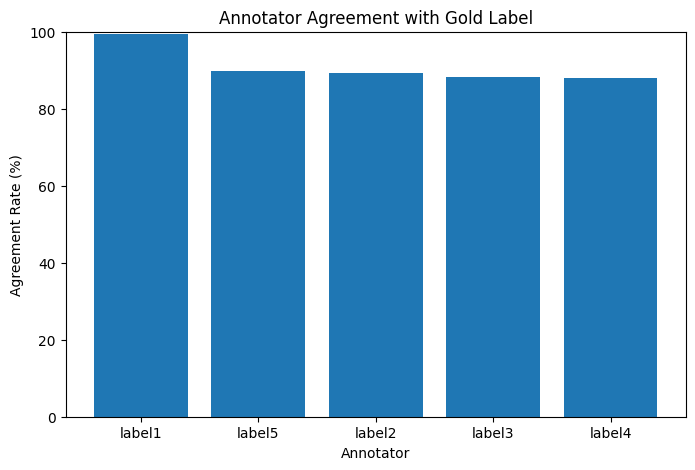

In [68]:
import matplotlib.pyplot as plt

annotator_plot = annotator_quality.sort_values(by='agree_percent', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(annotator_plot.index, annotator_plot['agree_percent'])

plt.title("Annotator Agreement with Gold Label")
plt.xlabel("Annotator")
plt.ylabel("Agreement Rate (%)")
plt.ylim(0, 100)

plt.show()

## Label Noise

Label noise occurs when the recorded label does not accurately represent the true relationship between the sentence pair.

In human-labeled datasets, label noise may arise from several sources:

- Annotator disagreement
- Misinterpretation of sentence relationships
- Ambiguous examples that are difficult to label consistently

One common indicator of label noise is **low agreement between annotators**.

### Low-Confidence Labels vs Label Noise

There are scenarios where some rows contain **only one or two annotator labels**.  
These rows provide limited information about annotator agreement and dataset reliability.

Rather than treating these rows as label noise, we consider them **low-confidence labels**, because:

- There is insufficient annotation data to measure agreement
- A single annotator may still provide a correct label
- Additional annotations would be required to determine reliability

Therefore:

- **Low agreement across multiple annotators → potential label noise**
- **Only one or two annotations → low-confidence labels**

Distinguishing between these cases helps avoid incorrectly discarding potentially valid data.

In [69]:
# First compute how many labels each row has.
# Look at rows where labels are =5. It gives me the most confident.
# labels = 4
# labels = 3
# labels = 2
# labels = 1
label_cols = ['label1', 'label2', 'label3', 'label4', 'label5']

df_train['label_count'] = df_train[label_cols].notna().sum(axis=1)
matches = df_train[label_cols].eq(df_train['gold_label'], axis=0)
df_train['number_of_labels_matching_gold'] = matches.sum(axis=1)
df_train['agree_percent'] = (df_train['number_of_labels_matching_gold'] / df_train['label_count']) * 100


# Generate df with label_count in 5, 4, 3, 2, 1.
df_5_labels = df_train[df_train['label_count'] == 5] # Very Confident
df_4_labels = df_train[df_train['label_count'] == 4]
df_3_labels = df_train[df_train['label_count'] == 3] # Moderate Confident
df_2_labels = df_train[df_train['label_count'] == 2]
df_1_label = df_train[df_train['label_count'] == 1] # Low Confident


# Take a look at the rows where all the labels exist. Identify the ones that agree_percent is < 60.
df_5_labels[df_5_labels['agree_percent'] <= 60] # Potential label noise >>> Downweight

df_4_labels[df_4_labels['agree_percent'] <= 60] # There are none
df_4_labels[df_4_labels['agree_percent'] <= 80] # It is pretty confindent but at the same time missing one annotator, possible downweight

df_3_labels[df_3_labels['agree_percent'] <= 60] # There are none
df_3_labels[df_3_labels['agree_percent'] <= 80] # There are none
df_3_labels[df_3_labels['agree_percent'] <= 100] # Moderate confindent, possible downweight.


# No 2 labels
df_2_labels[df_2_labels['agree_percent'] <= 60] # There are none
df_2_labels[df_2_labels['agree_percent'] <= 80] # There are none
df_2_labels[df_2_labels['agree_percent'] == 100] # There are none


df_1_label[df_1_label['agree_percent'] == 100] # Low confident, possibile downweight.

,gold_label,sentence1_binary_parse,sentence2_binary_parse,sentence1_parse,sentence2_parse,sentence1,sentence2,captionID,pairID,label1,label2,label3,label4,label5,label_count,number_of_labels_matching_gold,agree_percent
0,neutral,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,( ( A person ) ( ( is ( ( training ( his horse...,(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,A person is training his horse for a competition.,3416050480.jpg#4,3416050480.jpg#4r1n,neutral,NaN,NaN,NaN,NaN,1,1,100.0
1,contradiction,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,( ( A person ) ( ( ( ( is ( at ( a diner ) ) )...,(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",3416050480.jpg#4,3416050480.jpg#4r1c,contradiction,NaN,NaN,NaN,NaN,1,1,100.0
2,entailment,( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...,"( ( A person ) ( ( ( ( is outdoors ) , ) ( on ...",(ROOT (S (NP (NP (DT A) (NN person)) (PP (IN o...,(ROOT (S (NP (DT A) (NN person)) (VP (VBZ is) ...,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",3416050480.jpg#4,3416050480.jpg#4r1e,entailment,NaN,NaN,NaN,NaN,1,1,100.0
3,neutral,( Children ( ( ( smiling and ) waving ) ( at c...,( They ( are ( smiling ( at ( their parents ) ...,(ROOT (NP (S (NP (NNP Children)) (VP (VBG smil...,(ROOT (S (NP (PRP They)) (VP (VBP are) (VP (VB...,Children smiling and waving at camera,They are smiling at their parents,2267923837.jpg#2,2267923837.jpg#2r1n,neutral,NaN,NaN,NaN,NaN,1,1,100.0
4,entailment,( Children ( ( ( smiling and ) waving ) ( at c...,( There ( ( are children ) present ) ),(ROOT (NP (S (NP (NNP Children)) (VP (VBG smil...,(ROOT (S (NP (EX There)) (VP (VBP are) (NP (NN...,Children smiling and waving at camera,There are children present,2267923837.jpg#2,2267923837.jpg#2r1e,entailment,NaN,NaN,NaN,NaN,1,1,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550147,contradiction,( ( ( ( Four dirty ) and ) ( barefooted childr...,( ( four kids ) ( ( won awards ) ( ( ( for ` )...,(ROOT (NP (NP (CD Four) (NNS dirty)) (CC and) ...,(ROOT (S (NP (CD four) (NNS kids)) (VP (VBD wo...,Four dirty and barefooted children.,four kids won awards for 'cleanest feet',2267923837.jpg#3,2267923837.jpg#3r1c,contradiction,NaN,NaN,NaN,NaN,1,1,100.0
550148,neutral,( ( ( ( Four dirty ) and ) ( barefooted childr...,( ( ( ( ( ( four ( homeless children ) ) ( had...,(ROOT (NP (NP (CD Four) (NNS dirty)) (CC and) ...,(ROOT (S (S (NP (CD four) (JJ homeless) (NNS c...,Four dirty and barefooted children.,"four homeless children had their shoes stolen,...",2267923837.jpg#3,2267923837.jpg#3r1n,neutral,NaN,NaN,NaN,NaN,1,1,100.0
550149,neutral,( ( A man ) ( ( is ( surfing ( in ( ( a bodysu...,( ( ( A man ) ( in ( a bodysuit ) ) ) ( ( is (...,(ROOT (S (NP (DT A) (NN man)) (VP (VBZ is) (VP...,(ROOT (S (NP (NP (DT A) (NN man)) (PP (IN in) ...,A man is surfing in a bodysuit in beautiful bl...,A man in a bodysuit is competing in a surfing ...,7979219683.jpg#2,7979219683.jpg#2r1n,neutral,NaN,NaN,NaN,NaN,1,1,100.0
550150,contradiction,( ( A man ) ( ( is ( surfing ( in ( ( a bodysu...,( ( ( A man ) ( in ( a ( business suit ) ) ) )...,(ROOT (S (NP (DT A) (NN man)) (VP (VBZ is) (VP...,(ROOT (S (NP (NP (DT A) (NN man)) (PP (IN in) ...,A man is surfing in a bodysuit in beautiful bl...,A man in a business suit is heading to a board...,7979219683.jpg#2,7979219683.jpg#2r1c,contradiction,NaN,NaN,NaN,NaN,1,1,100.0


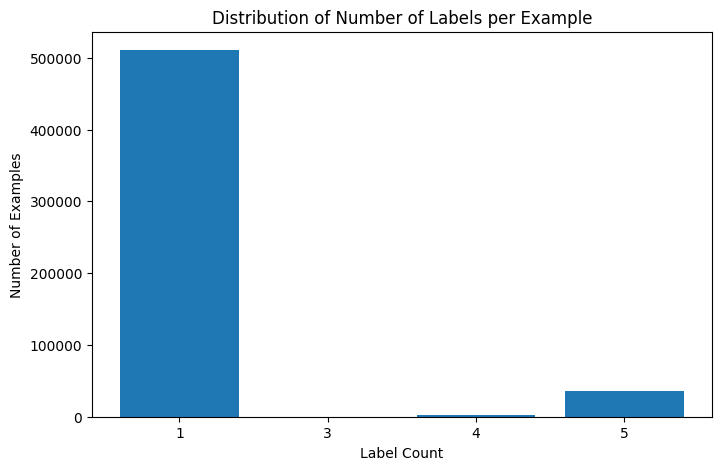

In [70]:
label_count_dist = df_train['label_count'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(label_count_dist.index.astype(str), label_count_dist.values)

plt.title("Distribution of Number of Labels per Example")
plt.xlabel("Label Count")
plt.ylabel("Number of Examples")

plt.show()

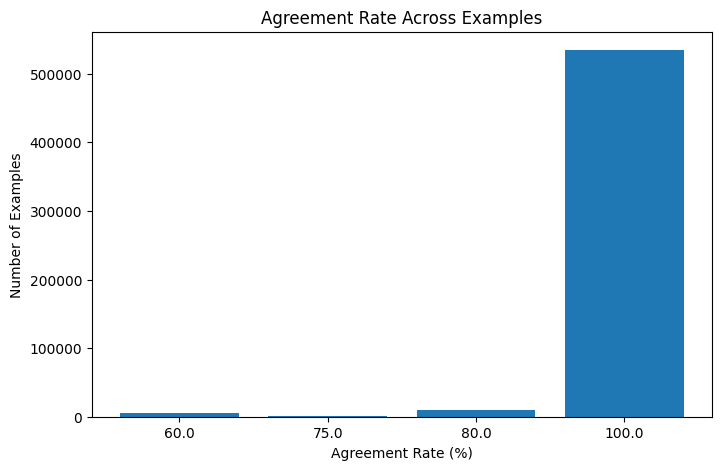

In [71]:
agreement_summary = df_train['agree_percent'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(agreement_summary.index.astype(str), agreement_summary.values)

plt.title("Agreement Rate Across Examples")
plt.xlabel("Agreement Rate (%)")
plt.ylabel("Number of Examples")

plt.show()

## Improving Dataset Quality

Based on the analysis of annotator agreement and reliability, we propose a weighting strategy to improve the quality of the training dataset.

The goal is to **reduce the influence of noisy labels while emphasizing more reliable annotations**.

The weighting strategy considers three factors:

1. Annotator reliability
2. Annotator agreement
3. Number of labels per example

### Annotator Reliability

First, we estimate annotator reliability by measuring how often each annotator agrees with the final gold label.

Example annotator accuracy scores:

In [72]:
annotator_accuracy = {
'label1': 99.537650,
'label5': 89.762245,
'label2': 89.243885,
'label3': 88.265451,
'label4': 87.968815
}

To convert these scores into weights, we normalize them relative to the highest accuracy score.

In [73]:
max_acc = max(annotator_accuracy.values())

annotator_weights = {k: v / max_acc for k, v in annotator_accuracy.items()}

label1 → 1.00  
label5 → 0.90  
label2 → 0.90  
label3 → 0.89  
label4 → 0.88

These weights reflect the relative reliability of each annotator.

For each row, we compute the average annotator reliability score.

### Label Count Weight

The number of annotations per example also affects confidence.

Examples with more annotators provide stronger consensus signals.

We assign weights based on the number of labels:
| Label Count | Weight |
| ----------- | ------ |
| 5           | 1.0    |
| 4           | 0.8    |
| 3           | 0.6    |
| 2           | 0.4    |
| 1           | 0.2    |

### Annotator Agreement

Higher agreement between annotators indicates stronger consensus.

Agreement weights are assigned as follows:

| Agreement Rate | Weight |
| -------------- | ------ |
| 100%           | 1.0    |
| 80%            | 0.8    |
| 60%            | 0.6    |
| 40%            | 0.4    |
| 20%            | 0.2    |


### Final Row Weight
Each example receives a final weight based on the combination of these three factors.

**Row_weight = annotator_quality × agreement × label_count**

Where:

* annotator_quality = average normalized annotator reliability
* agreement = agreement weight
* label_count = annotation count weight


This weighting framework reduces the influence of noisy labels while emphasizing more reliable examples.

## Evaluating Impact on Model Performance

The quality of training labels has a direct impact on model performance. When models are trained on datasets containing inconsistent or noisy annotations, the learned patterns may not accurately reflect the true relationships in the data.

In the SNLI dataset, each example is annotated by multiple human annotators. Disagreements between annotators may indicate ambiguity in the sentence pair or potential labeling errors. These inconsistencies can introduce **label noise**, which may negatively affect model evaluation metrics.

For example:

• **Accuracy** may decrease if the training data contains incorrect labels, causing the model to learn misleading patterns.  

• **Precision** may be affected when noisy labels cause the model to incorrectly predict a class more frequently.  

• **Recall** may decrease if the model fails to learn the correct signals for identifying a particular relationship between sentences.  

• **F1 Score**, which balances precision and recall, may decline when label noise disrupts the model’s ability to distinguish between entailment, neutral, and contradiction.

The annotator reliability analysis conducted in this notebook highlights several factors that could influence model performance:

• **Annotator disagreement**, which may indicate ambiguous or difficult examples  
• **Low-confidence rows**, where only one or two annotations are available  
• **Differences in annotator reliability**, where some annotators align more consistently with the gold label

To improve training data quality and potentially improve model performance, several strategies could be applied:

- Use **majority voting** to determine the most reliable label for each example  
- Apply **annotator weighting** based on reliability scores  
- **Filter or review high-disagreement examples** that may contain label noise  
- Collect **additional annotations** for ambiguous samples

By improving the reliability of training labels, models trained on the dataset may achieve better performance across evaluation metrics such as **accuracy, precision, recall, and F1 score**.

## Key Takeaway

This notebook analyzes label noise and annotator reliability in the SNLI dataset and proposes a weighting framework to improve the quality of training data.